[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


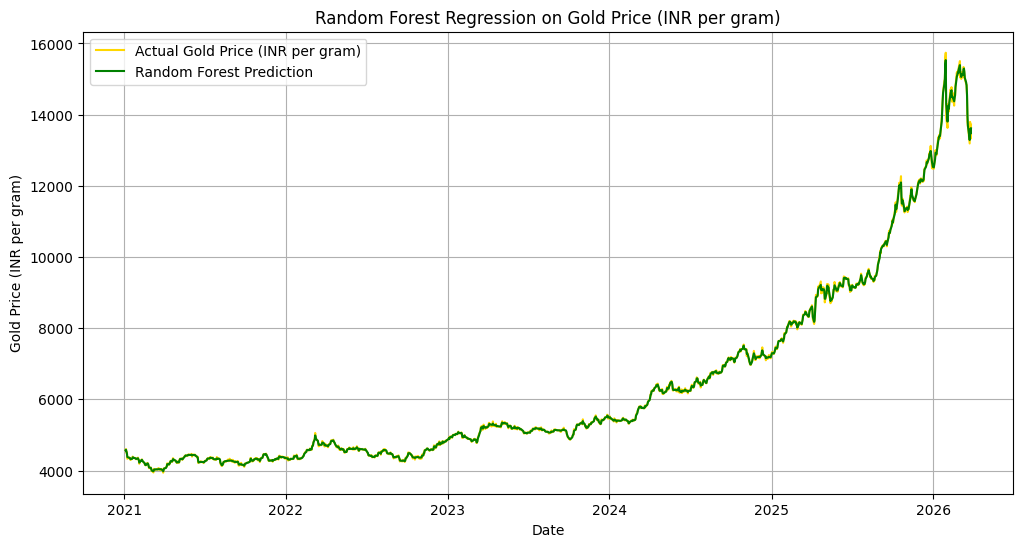

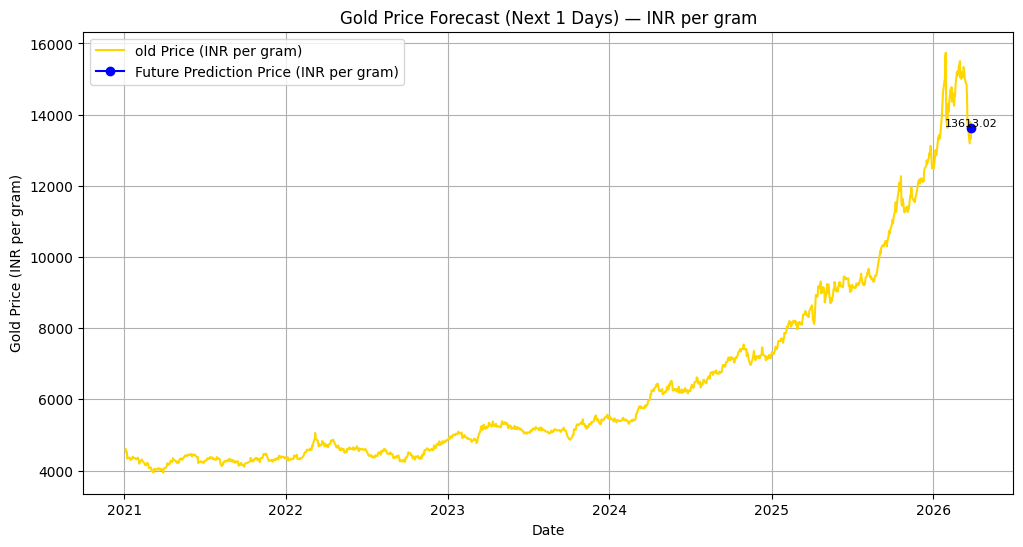

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
import yfinance as yf


gold = yf.download("GC=F", start="2021-01-01")
fx = yf.download("USDINR=X", start="2021-01-01")
gold.columns = gold.columns.get_level_values(0)
fx.columns = fx.columns.get_level_values(0)

# taking only Close prices
gold = gold[['Close']].rename(columns={'Close': 'Gold_USD'}).dropna()
fx = fx[['Close']].rename(columns={'Close': 'USDINR'}).dropna()

# Glod and INR in one table
df = gold.join(fx, how='inner')


df['Gold_INR'] = df['Gold_USD'] * df['USDINR']
# Convert ounce → gram
df['Gold_INR_per_gram'] = df['Gold_INR'] / 31.1034768
df['t'] = np.arange(len(df))

X = df[['t']]
y = df['Gold_INR_per_gram']

#Random Forest Model

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=12
)

rf.fit(X, y)

df['RF_Predicted'] = rf.predict(X)

# Plot actual vs predicted
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Gold_INR_per_gram'], label="Actual Gold Price (INR per gram)", color="gold")
plt.plot(df.index, df['RF_Predicted'], label="Random Forest Prediction", color="green")

plt.title("Random Forest Regression on Gold Price (INR per gram)")
plt.xlabel("Date")
plt.ylabel("Gold Price (INR per gram)")
plt.legend()
plt.grid(True)
plt.show()



future_days = 1   # Predict Next future_days = ?


future_t = pd.DataFrame({'t': np.arange(len(df), len(df) + future_days)})
future_pred = rf.predict(future_t)
future_dates = pd.date_range(start=df.index[-1], periods=future_days, freq='D')

plt.figure(figsize=(12,6))

# Historical line
plt.plot(df.index, df['Gold_INR_per_gram'], 
         label="old Price (INR per gram)", 
         color="gold")

# Future prediction line with markers
plt.plot(future_dates, future_pred, 
         label="Future Prediction Price (INR per gram)", 
         color="blue", marker='o')

# Add price labels on each predicted point
for date, price in zip(future_dates, future_pred):
    plt.text(date, price, f"{price:.2f}", 
             fontsize=8, ha='center', va='bottom')

plt.title(f"Gold Price Forecast (Next {future_days} Days) — INR per gram")
plt.xlabel("Date")
plt.ylabel("Gold Price (INR per gram)")
plt.legend()
plt.grid(True)
plt.show()